In [1]:
import pandas as pd
df = pd.read_csv('water_quality_readings.csv')
print(f"Loaded {len(df)} readings across {df['scenario'].nunique()} scenarios")
df.head(10)

Loaded 19 readings across 4 scenarios


,timestamp_ms,temp_c,tds_ppm,ph,turbidity_ntu,tds_alert,ph_alert,scenario
0,10002,25.0,0.00,14.0,0.09,False,True,default
1,20003,25.0,108.48,14.0,0.09,False,True,default
2,30003,25.0,108.48,14.0,0.09,False,True,default
3,40003,25.0,108.48,14.0,0.09,False,True,default
4,70003,25.0,108.48,6.9,0.09,False,False,clean_water
5,80003,25.0,108.48,6.9,0.09,False,False,clean_water
6,90003,25.0,108.48,6.9,0.09,False,False,clean_water
7,100003,25.0,108.48,6.9,0.09,False,False,clean_water
8,110003,25.0,108.48,6.9,0.09,False,False,clean_water
9,120003,25.0,108.48,6.9,743.62,False,False,clean_water


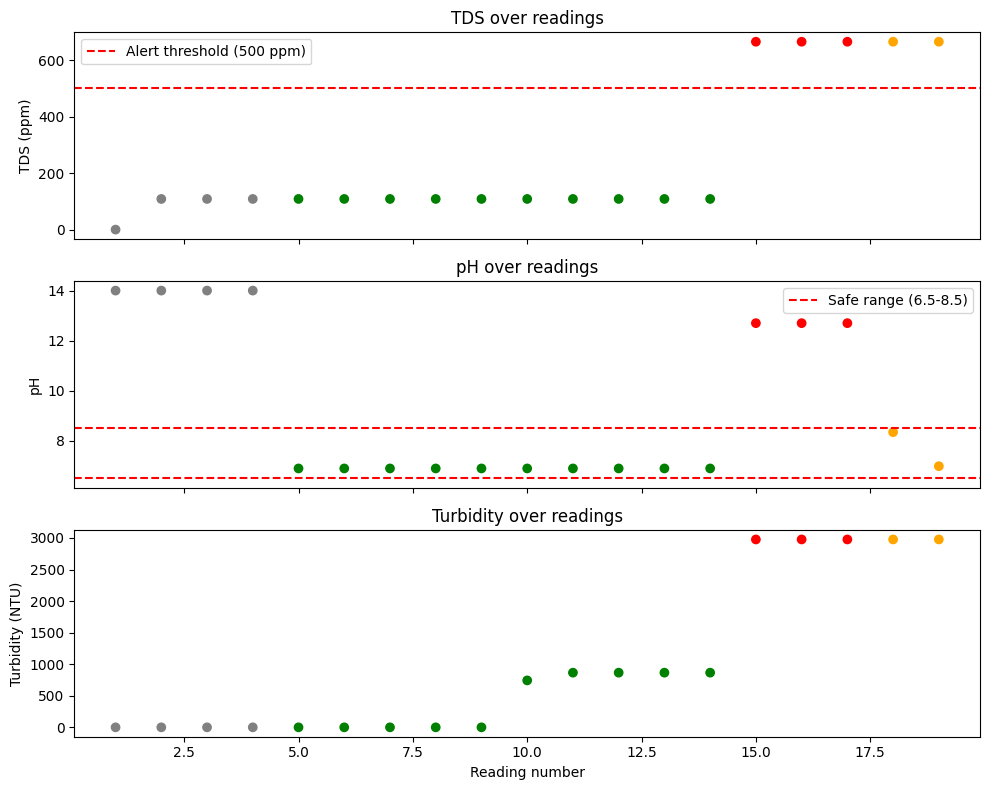

In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
df['reading_number'] = range(1, len(df) + 1)
colors = {'default': 'gray', 'clean_water': 'green', 'contaminated_water': 'red', 'borderline': 'orange'}
point_colors = df['scenario'].map(colors)

axes[0].scatter(df['reading_number'], df['tds_ppm'], c=point_colors)
axes[0].axhline(y=500, color='red', linestyle='--', label='Alert threshold (500 ppm)')
axes[0].set_ylabel('TDS (ppm)'); axes[0].legend(); axes[0].set_title('TDS over readings')

axes[1].scatter(df['reading_number'], df['ph'], c=point_colors)
axes[1].axhline(y=6.5, color='red', linestyle='--', label='Safe range (6.5-8.5)')
axes[1].axhline(y=8.5, color='red', linestyle='--')
axes[1].set_ylabel('pH'); axes[1].legend(); axes[1].set_title('pH over readings')

axes[2].scatter(df['reading_number'], df['turbidity_ntu'], c=point_colors)
axes[2].set_ylabel('Turbidity (NTU)'); axes[2].set_xlabel('Reading number'); axes[2].set_title('Turbidity over readings')

plt.tight_layout()
plt.show()

In [3]:
def explain_alert(row):
    reasons = []
    if row['tds_alert']:
        reasons.append(f"TDS {row['tds_ppm']:.1f} ppm > 500 ppm limit")
    if row['ph_alert']:
        reasons.append(f"pH {row['ph']:.2f} outside safe 6.5-8.5 range")
    return "; ".join(reasons)

df_clean = df[df['scenario'] != 'default'].copy()
df_clean['reading_number'] = range(1, len(df_clean) + 1)

alerts_clean = df_clean[(df_clean['tds_alert']) | (df_clean['ph_alert'])].copy()
alerts_clean['reason'] = alerts_clean.apply(explain_alert, axis=1)

print(f"Excluding {len(df) - len(df_clean)} idle/default readings.")
print(f"{len(alerts_clean)} of {len(df_clean)} real measurements triggered an alert ({len(alerts_clean)/len(df_clean)*100:.0f}%)\n")
print(alerts_clean[['reading_number', 'scenario', 'tds_ppm', 'ph', 'reason']].to_string(index=False))

Excluding 4 idle/default readings.
5 of 15 real measurements triggered an alert (33%)

 reading_number           scenario  tds_ppm    ph                                                             reason
             11 contaminated_water   664.82 12.70 TDS 664.8 ppm > 500 ppm limit; pH 12.70 outside safe 6.5-8.5 range
             12 contaminated_water   664.82 12.70 TDS 664.8 ppm > 500 ppm limit; pH 12.70 outside safe 6.5-8.5 range
             13 contaminated_water   664.82 12.70 TDS 664.8 ppm > 500 ppm limit; pH 12.70 outside safe 6.5-8.5 range
             14         borderline   664.82  8.35                                      TDS 664.8 ppm > 500 ppm limit
             15         borderline   664.82  6.99                                      TDS 664.8 ppm > 500 ppm limit


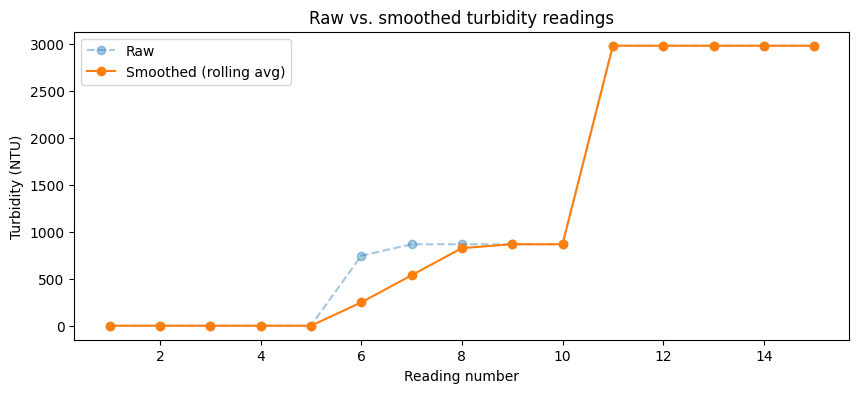

,reading_number,scenario,turbidity_ntu,turbidity_ntu_smoothed
0,1,clean_water,0.09,0.090000
1,2,clean_water,0.09,0.090000
2,3,clean_water,0.09,0.090000
3,4,clean_water,0.09,0.090000
4,5,clean_water,0.09,0.090000
5,6,clean_water,743.62,247.933333
6,7,clean_water,866.07,536.593333
7,8,clean_water,866.07,825.253333
8,9,clean_water,866.07,866.070000
9,10,clean_water,866.07,866.070000


In [4]:
df_clean = df_clean.sort_values('reading_number').reset_index(drop=True)
for col in ['tds_ppm', 'ph', 'turbidity_ntu']:
    df_clean[f'{col}_smoothed'] = (
        df_clean.groupby('scenario')[col]
        .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
    )

plt.figure(figsize=(10, 4))
plt.plot(df_clean['reading_number'], df_clean['turbidity_ntu'], 'o--', alpha=0.4, label='Raw')
plt.plot(df_clean['reading_number'], df_clean['turbidity_ntu_smoothed'], 'o-', label='Smoothed (rolling avg)')
plt.xlabel('Reading number'); plt.ylabel('Turbidity (NTU)'); plt.title('Raw vs. smoothed turbidity readings')
plt.legend()
plt.show()

df_clean[['reading_number', 'scenario', 'turbidity_ntu', 'turbidity_ntu_smoothed']]